In [1]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from keras.utils import plot_model
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, MaxPool2D, Flatten, Conv2D
from keras.utils import to_categorical
import tensorflow as tf
from scipy.stats import mode
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import StandardScaler
import glob
import os
import tifffile

In [2]:
tf.random.set_seed(221)

# 1. Data Loading, Processing, and Exploration

**Visit the EuroSAT data description page and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.**

In [3]:
batch_size = 16
img_width = 64
img_height = 64

In [4]:
image_generator = ImageDataGenerator().flow_from_directory(
    'EuroSAT_RGB',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    seed=42)

Found 27000 images belonging to 10 classes.


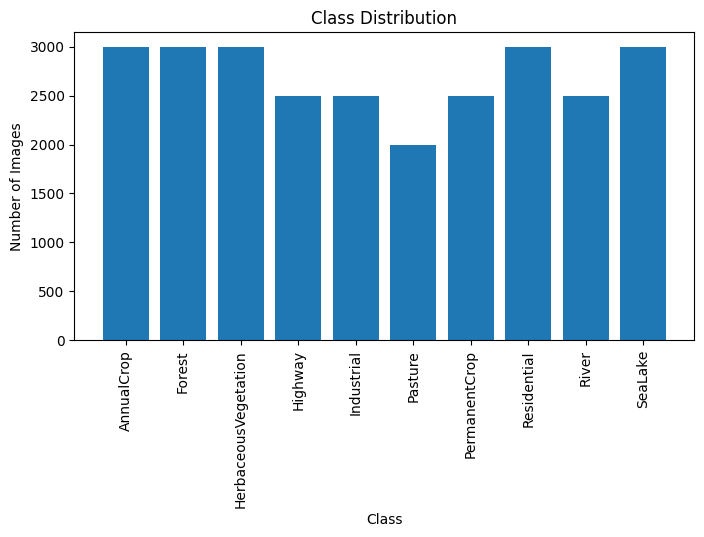

In [5]:
class_labels = image_generator.classes
counter = Counter(class_labels)

class_indices = image_generator.class_indices
inv_class_indices = {v: k for k, v in class_indices.items()}

classes_sorted = [inv_class_indices[i] for i in sorted(inv_class_indices.keys())]
count_values = [counter[i] for i in sorted(inv_class_indices.keys())]

plt.figure(figsize=(8, 4))
plt.bar(classes_sorted, count_values)
plt.xlabel("Class")
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

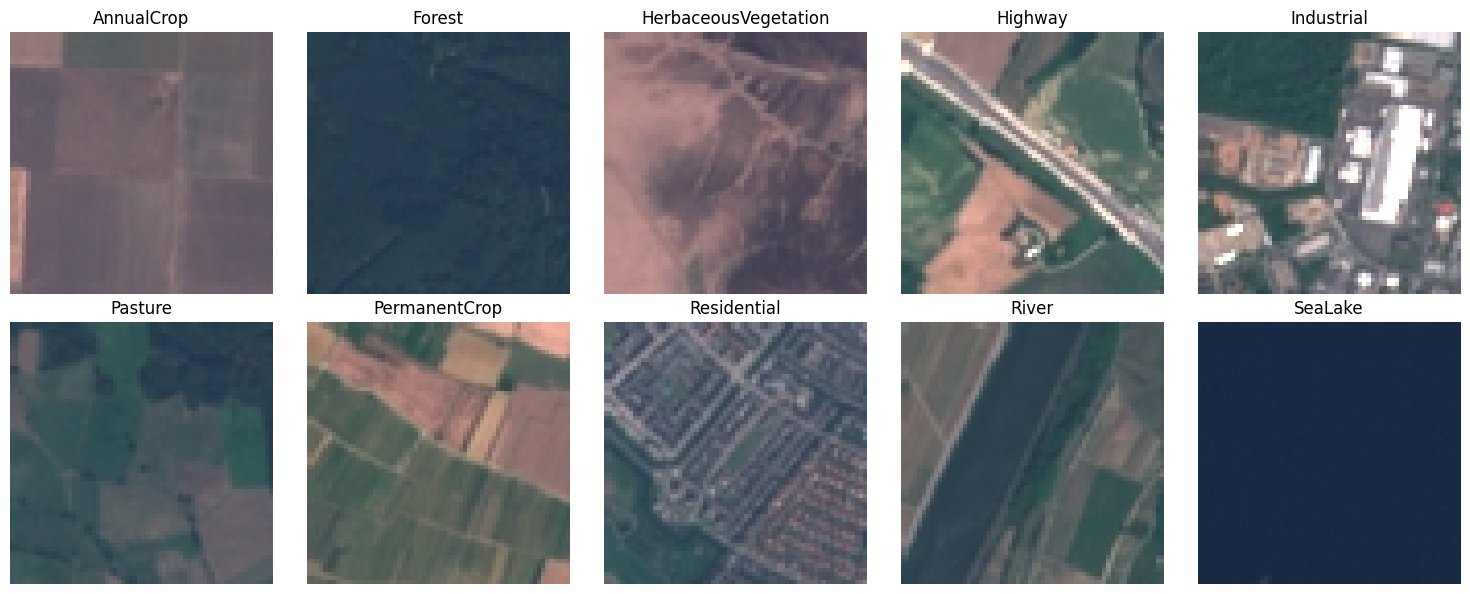

In [6]:
chosen_images = {}
for f in image_generator.filenames:
    class_name = f.split(os.sep)[0]
    if class_name not in chosen_images:
        chosen_images[class_name] = os.path.join(image_generator.directory, f)
    if len(chosen_images) >= len(class_indices):
        break

plt.figure(figsize=(15, 6))

for idx, class_name in enumerate([inv_class_indices[i] for i in sorted(inv_class_indices.keys())]):
    img_path = chosen_images[class_name]
    img = plt.imread(img_path)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

**Flatten the images into a 2D data matrix (x x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into the numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).**

In [7]:
all_images = []
all_labels = []
steps = int(np.ceil(image_generator.samples / batch_size))

for i in range(steps):
    batch_images, batch_labels = next(image_generator)
    all_images.append(batch_images)
    all_labels.append(batch_labels)

all_images = np.concatenate(all_images, axis=0).reshape((-1, img_width*img_height, 3))
all_labels = np.concatenate(all_labels, axis=0)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.4, stratify=all_labels, random_state=42
)

**Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.**

In [9]:
weights = np.array([0.2989, 0.5870, 0.1140], dtype=np.float32)

X_train_gray = np.dot(X_train, weights)
X_test_gray = np.dot(X_test, weights)

# 2. Traditional Machine Learning

**For this first section, we will only use the categories "Forest (F)", "Residential (R)" and "Industrial (I)". Make sure to subset the grayscale dataset, select only for these three classes.**

In [10]:
inv_class_indices

{0: 'AnnualCrop',
 1: 'Forest',
 2: 'HerbaceousVegetation',
 3: 'Highway',
 4: 'Industrial',
 5: 'Pasture',
 6: 'PermanentCrop',
 7: 'Residential',
 8: 'River',
 9: 'SeaLake'}

In [11]:
subset_idx_train = np.where((y_train == 1) | (y_train == 4) | (y_train == 7))[0]
X_train_gray_subset = X_train_gray[subset_idx_train]
y_train_subset = y_train[subset_idx_train]

subset_idx_test = np.where((y_test == 1) | (y_test == 4) | (y_test == 7))[0]
X_test_gray_subset = X_test_gray[subset_idx_test]
y_test_subset = y_test[subset_idx_test]

## 2.1 Binary Support Vector Machine

**Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I] and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.**

In [12]:
def svm_2_1(class_a, class_b, X_train, y_train, X_test, y_test):
    subset_idx = np.where((y_train == class_a) | (y_train == class_b))[0]
    X_train_subset = X_train[subset_idx]

    y_train_subset = y_train[subset_idx]
    y_train_binary = (y_train_subset == class_a).astype(int)

    subset_idx_test = np.where((y_test == class_a) | (y_test == class_b))[0]
    X_test_subset = X_test[subset_idx_test]

    y_test_subset = y_test[subset_idx_test]
    y_test_binary = (y_test_subset == class_a).astype(int)

    clf = SVC(kernel='linear', probability=True, random_state=42)
    clf.fit(X_train_subset, y_train_binary)
    y_pred = clf.predict(X_test_subset)
    accuracy = accuracy_score(y_test_binary, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test_binary, clf.predict_proba(X_test_subset)[:, 1])
    roc_auc = auc(fpr, tpr)

    print(f"Accuracy: {accuracy:.4f}")
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

    misclassified = np.where(y_pred != y_test_binary)[0]
    idx = misclassified[0]
    misclassified_img = X_train_subset[idx].reshape(img_height, img_width)

    plt.imshow(misclassified_img, cmap='gray')
    plt.title(f"True: {inv_class_indices[class_a]}, Predicted: {inv_class_indices[class_b]}")
    plt.axis('off')
    plt.show()

    return clf

Accuracy: 0.9383


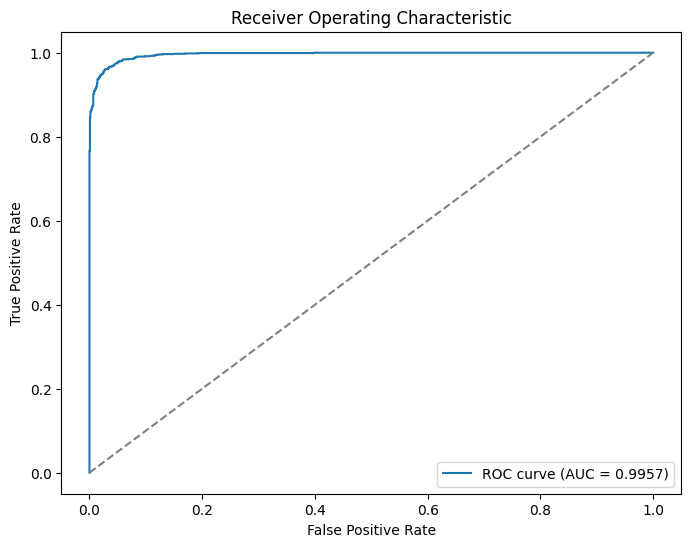

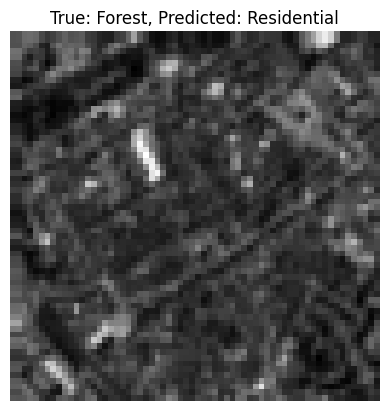

In [13]:
svm_f_v_r = svm_2_1(1, 7, X_train_gray_subset, y_train_subset, X_test_gray_subset, y_test_subset)

Accuracy: 0.9955


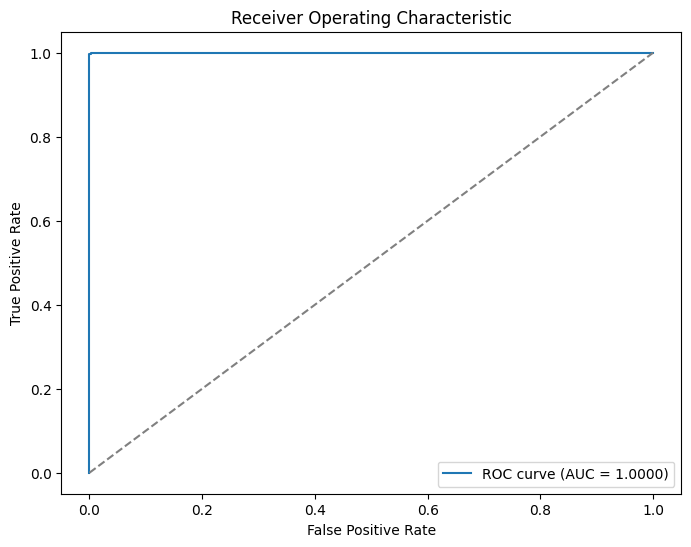

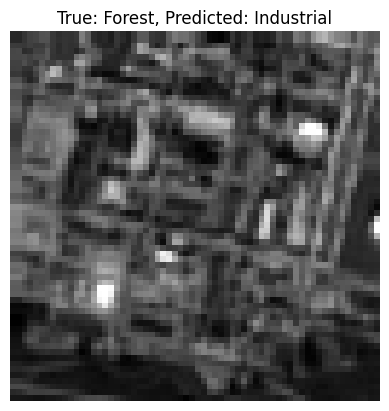

In [14]:
svm_f_v_i = svm_2_1(1, 4, X_train_gray_subset, y_train_subset, X_test_gray_subset, y_test_subset)

Accuracy: 0.7177


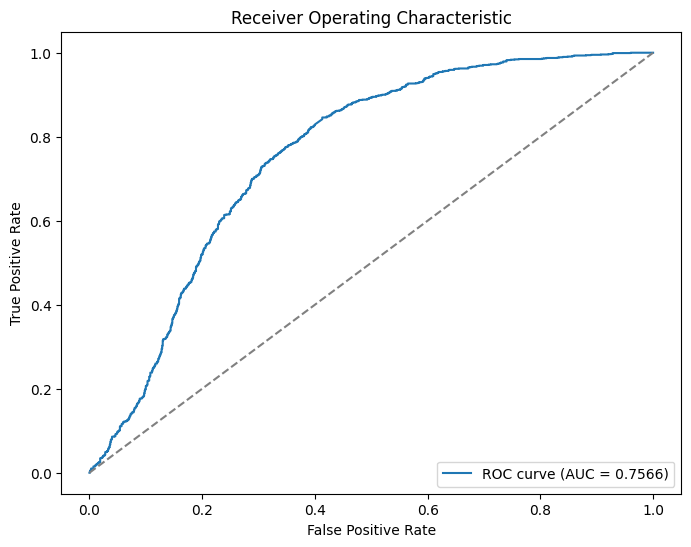

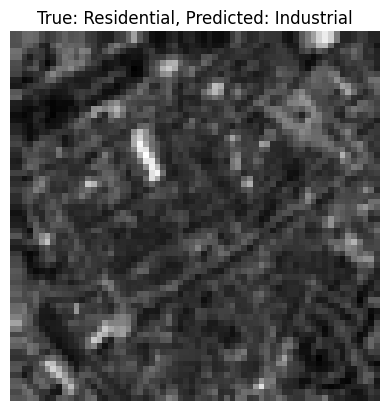

In [15]:
svm_r_v_i = svm_2_1(7, 4, X_train_gray_subset, y_train_subset, X_test_gray_subset, y_test_subset)

## 2.2 Multiclass, Majority-Vote Support Vector Machine

**Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.**

In [16]:
def binary_pred_to_label (svm, X_train_gray_subset, label_change_dict):
    predicted_label = svm.predict(X_train_gray_subset)
    predicted_label = np.vectorize(label_change_dict.get)(predicted_label)

    return predicted_label

In [17]:
svm_f_v_r_label = binary_pred_to_label(svm_f_v_r, X_test_gray_subset, {1:1, 0:7})
svm_f_v_i_label = binary_pred_to_label(svm_f_v_i, X_test_gray_subset, {1:1, 0:4})
svm_r_v_i_label = binary_pred_to_label(svm_r_v_i, X_test_gray_subset, {1:7, 0:4})

In [18]:
combined_pred = np.concatenate((svm_f_v_r_label.reshape(-1, 1),
                                            svm_f_v_i_label.reshape(-1, 1),
                                            svm_r_v_i_label.reshape(-1, 1)), axis=1)
majority_voting_label = mode(combined_pred, axis=1).mode.flatten()

In [19]:
accuracy_multi = accuracy_score(y_test_subset, majority_voting_label)
print(f"Multi-class Majority Vote Accuracy: {accuracy_multi:.4f}")

Multi-class Majority Vote Accuracy: 0.7768


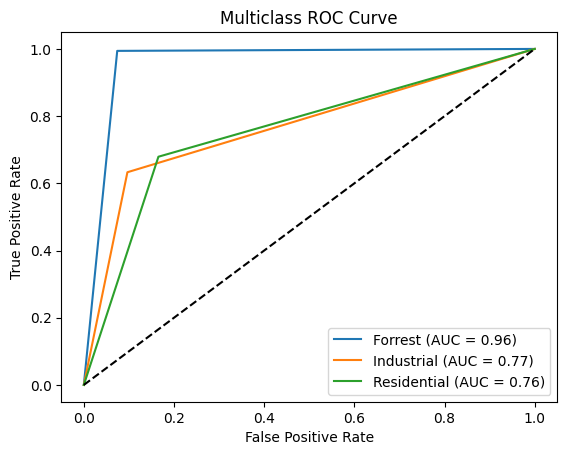

In [20]:
fpr, tpr, roc_auc = {}, {}, {}
dict_to_classes = {0:1, 1:4, 2:7}
lb = LabelBinarizer()
majority_voting_label_bin = lb.fit_transform(majority_voting_label)
for i in range(3):
    y_test_subset_binary = (y_test_subset == dict_to_classes[i]).astype(int)
    fpr[i], tpr[i], _ = roc_curve(y_test_subset_binary, majority_voting_label_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
dict_to_classes_names = {0: 'Forrest', 1: 'Industrial', 2: 'Residential'}
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'{dict_to_classes_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend()
plt.show()

In [21]:
def misclassified_images_fun(y_pred_multi, y_test_subset):
    misclassified_multi_class = np.where(y_pred_multi != y_test_subset)[0]
    np.random.shuffle(misclassified_multi_class)

    misclassified_images = []
    true_labels_done = []
    dict_to_classes_names = {1: 'Forrest', 4: 'Industrial', 7: 'Residential'}

    for idx in misclassified_multi_class:
        misclassified_img = X_test_gray_subset[idx].reshape(img_height, img_width)
        true_label = y_test_subset[idx]
        predicted_label = y_pred_multi[idx]
        
        if true_label not in true_labels_done:
            misclassified_images.append((misclassified_img, true_label, dict_to_classes_names[predicted_label]))
            true_labels_done.append(true_label)

    return misclassified_images

In [22]:
misclassified_images = misclassified_images_fun(majority_voting_label, y_test_subset)

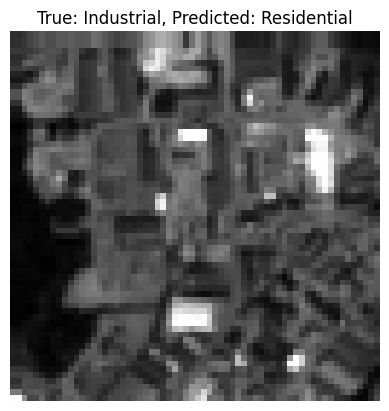

In [23]:
i = 0 
plt.imshow(misclassified_images[i][0], cmap='gray')
plt.title(f"True: {inv_class_indices[misclassified_images[i][1]]}, Predicted: {misclassified_images[i][2]}")
plt.axis('off')
plt.show()

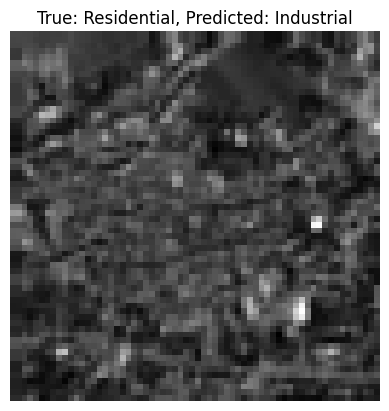

In [24]:
i = 1
plt.imshow(misclassified_images[i][0], cmap='gray')
plt.title(f"True: {inv_class_indices[misclassified_images[i][1]]}, Predicted: {misclassified_images[i][2]}")
plt.axis('off')
plt.show()

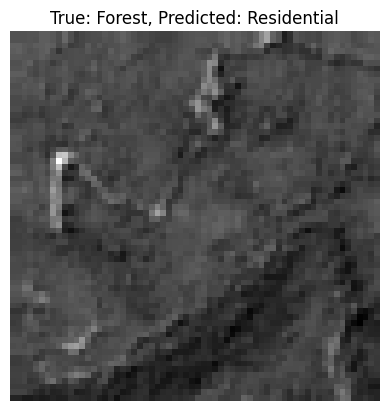

In [25]:
i = 2
plt.imshow(misclassified_images[i][0], cmap='gray')
plt.title(f"True: {inv_class_indices[misclassified_images[i][1]]}, Predicted: {misclassified_images[i][2]}")
plt.axis('off')
plt.show()

## 2.3 Multiclass Random Forest

**Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.**

In [26]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train_gray_subset, y_train_subset)
y_pred_rf = rf_model.predict(X_test_gray_subset)
accuracy_rf = accuracy_score(y_test_subset, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.9162


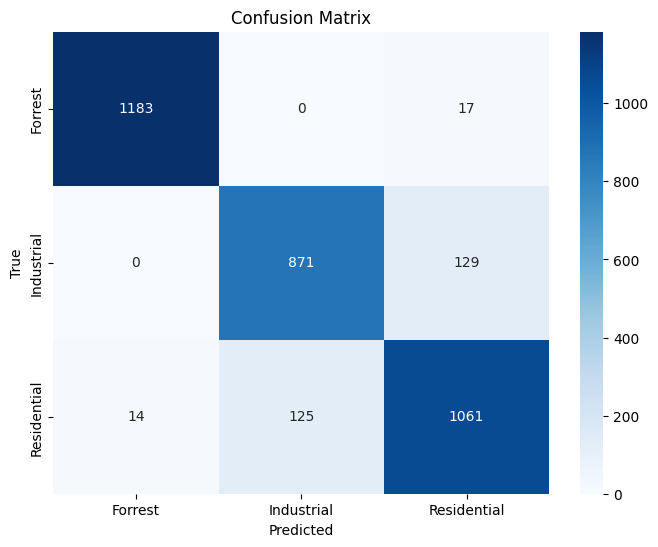

In [27]:
cm = confusion_matrix(y_test_subset, y_pred_rf)
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dict_to_classes_names.values(), yticklabels=dict_to_classes_names.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [28]:
misclassified_images = misclassified_images_fun(y_pred_rf, y_test_subset)

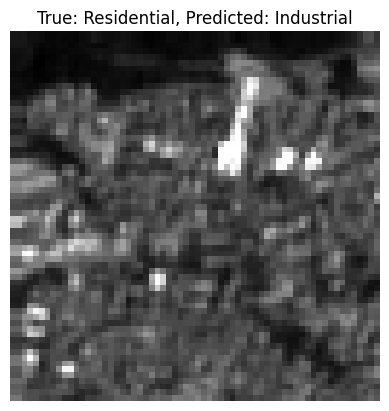

In [29]:
i = 0 
plt.imshow(misclassified_images[i][0], cmap='gray')
plt.title(f"True: {inv_class_indices[misclassified_images[i][1]]}, Predicted: {misclassified_images[i][2]}")
plt.axis('off')
plt.show()

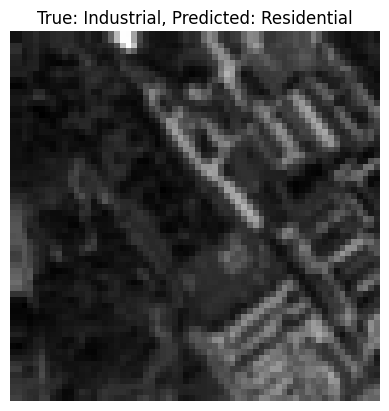

In [30]:
i = 1
plt.imshow(misclassified_images[i][0], cmap='gray')
plt.title(f"True: {inv_class_indices[misclassified_images[i][1]]}, Predicted: {misclassified_images[i][2]}")
plt.axis('off')
plt.show()

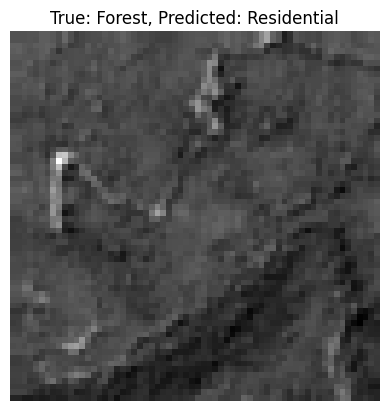

In [31]:
i = 2
plt.imshow(misclassified_images[i][0], cmap='gray')
plt.title(f"True: {inv_class_indices[misclassified_images[i][1]]}, Predicted: {misclassified_images[i][2]}")
plt.axis('off')
plt.show()

# 3. Deep Learning

**For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.**

In [32]:
num_classes = len(class_indices)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

## 3.1 Greyscale Images

### 3.1.1 Model One

**Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e: input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)**

In [33]:
X_train_gray = X_train_gray / 255
X_test_gray = X_test_gray / 255

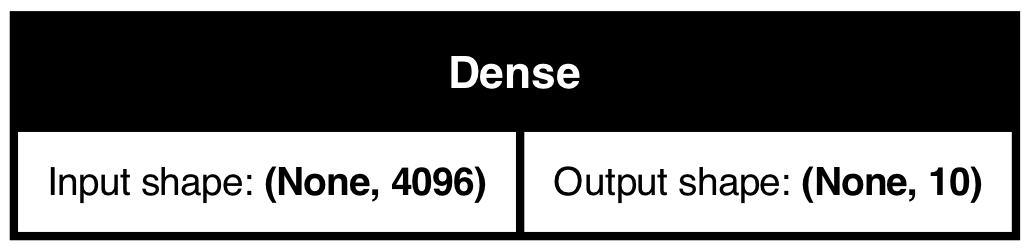

In [34]:
model_one_nn = Sequential([
    Input(shape=(img_width * img_height,)),
    Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=1))
])

model_one_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

plot_model(model_one_nn, to_file='model_one_nn.png', show_shapes=True)

In [35]:
history = model_one_nn.fit(X_train_gray, y_train_cat, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1245 - loss: 2.4461 - val_accuracy: 0.1531 - val_loss: 2.3016
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1657 - loss: 2.3215 - val_accuracy: 0.1556 - val_loss: 2.2581
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.1841 - loss: 2.2861 - val_accuracy: 0.1889 - val_loss: 2.2334
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - accuracy: 0.2020 - loss: 2.2568 - val_accuracy: 0.2556 - val_loss: 2.2155
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.2140 - loss: 2.2307 - val_accuracy: 0.2815 - val_loss: 2.2008
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.2265 - loss: 2.2070 - val_accuracy: 0.2932 - val_loss: 2.1878
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.2372 - loss: 2.1853 - val_accuracy: 0.2944 - val_loss: 2.1758
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.2444 - loss: 2.1653 - val_

In [36]:
loss, accuracy = model_one_nn.evaluate(X_test_gray, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.2775 - loss: 2.1609
Test accuracy: 0.2793


For the pre-processing step, we converted our labels into a one-hot encoded matrix, as the neural network's predicted output is a vector of shape 10. Since the network requires a similarly structured ground truth vector to compute the loss, one-hot encoding ensures compatibility.

### 3.1.2 Model Two

**Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?**

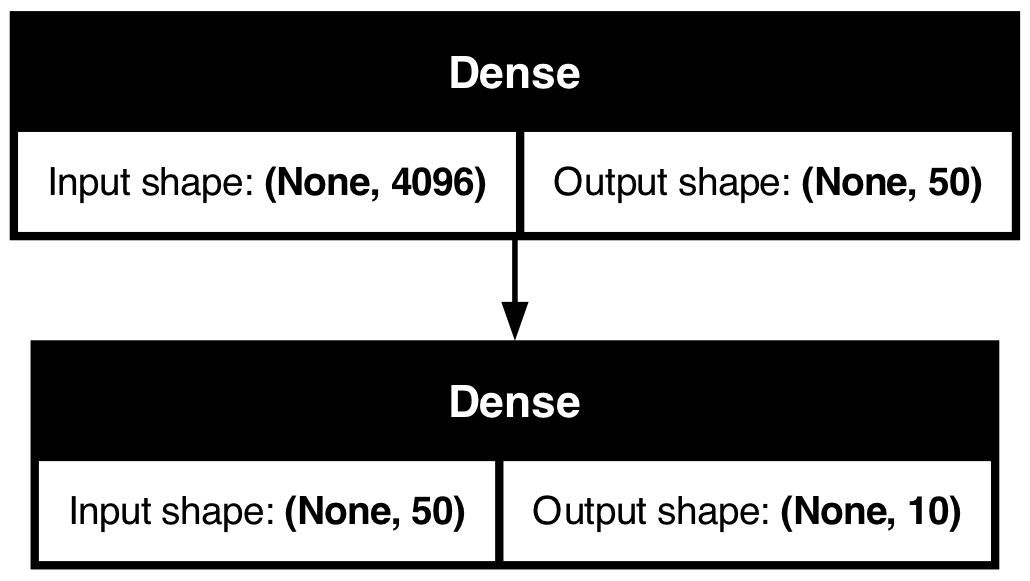

In [37]:
model_two_nn = Sequential([
    Input(shape=(img_width * img_height,)),
    Dense(50, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=1)),
    Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=1))
])

model_two_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

plot_model(model_two_nn, to_file='model_two_nn.png', show_shapes=True)

In [38]:
history = model_two_nn.fit(X_train_gray, y_train_cat, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1264 - loss: 2.7948 - val_accuracy: 0.1444 - val_loss: 2.3751
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1788 - loss: 2.3356 - val_accuracy: 0.1383 - val_loss: 2.3372
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2102 - loss: 2.1744 - val_accuracy: 0.2148 - val_loss: 2.0709
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2297 - loss: 2.0668 - val_accuracy: 0.2679 - val_loss: 2.0047
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2534 - loss: 2.0039 - val_accuracy: 0.2562 - val_loss: 1.9900
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2557 - loss: 1.9670 - val_accuracy: 0.2735 - val_loss: 1.9491
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2606 - loss: 1.9413 - val_accuracy: 0.2870 - val_loss: 1.9249
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2680 - loss: 1.9241 - val_accuracy: 0.

In [39]:
loss, accuracy = model_two_nn.evaluate(X_test_gray, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - accuracy: 0.2993 - loss: 1.8921
Test accuracy: 0.3049


Our test accuracy, while still low, shows some improvement, though not a significant leap from the first model. The additional hidden layer helps capture the dataset's non-linearities, which the first model struggled with due to having only a single dense layer. However, in some cases, accuracy may decline. Adding more layers introduces challenges such as overfitting and issues like vanishing or exploding gradients, where gradients become extremely small or large during backpropagation, hindering effective learning.

### 3.1.3 Model Three

**Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model’s performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.**

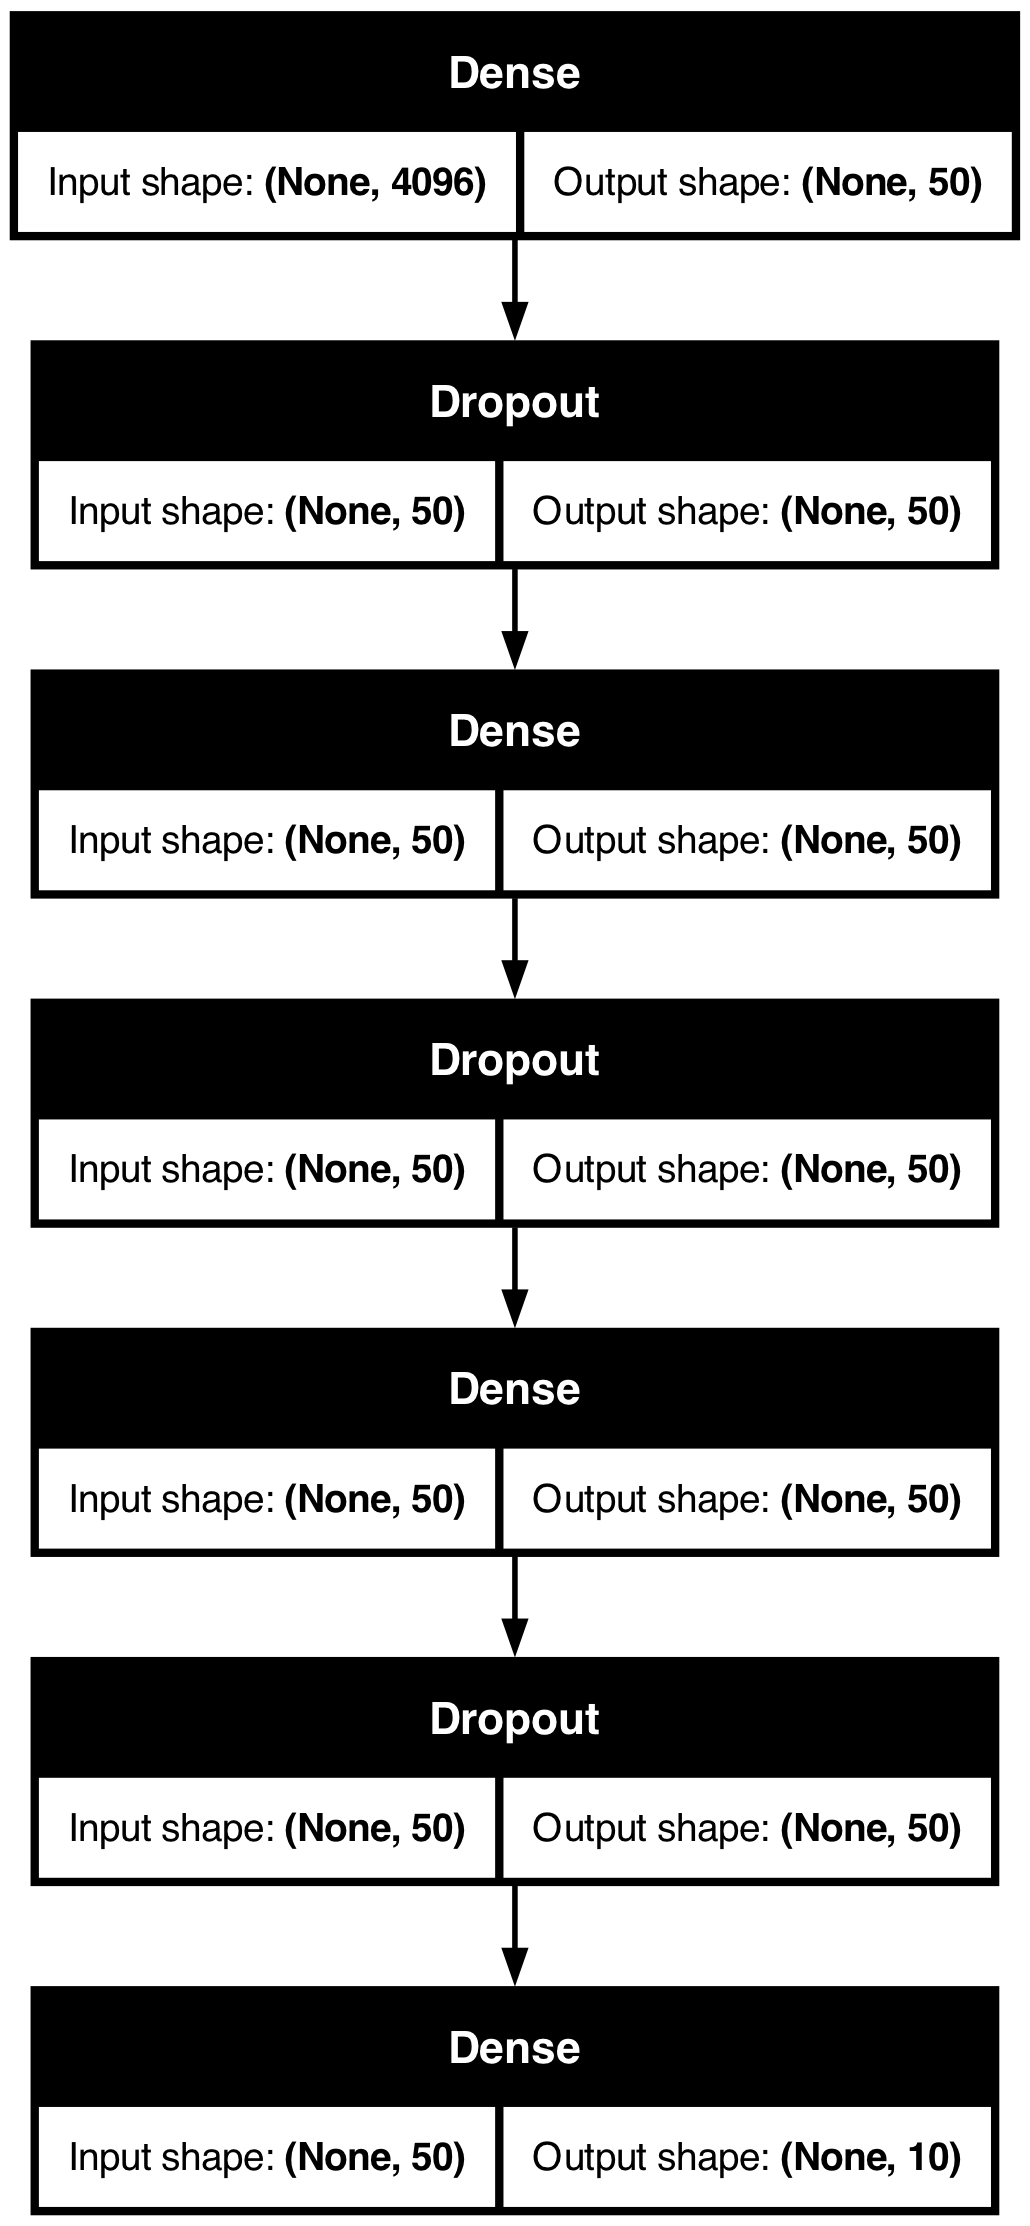

In [40]:
model_three_nn = Sequential([
    Input(shape=(img_width * img_height,)),
    Dense(50, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    Dropout(0.3, seed=42),
    Dense(50, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    Dropout(0.3, seed=42),
    Dense(50, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    Dropout(0.3, seed=42),
    Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10))
])

model_three_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

plot_model(model_three_nn, to_file='model_three_nn.png', show_shapes=True)

In [41]:
history = model_three_nn.fit(X_train_gray, y_train_cat, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1193 - loss: 3.1156 - val_accuracy: 0.1420 - val_loss: 2.1746
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1595 - loss: 2.3628 - val_accuracy: 0.1864 - val_loss: 2.1326
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1898 - loss: 2.1995 - val_accuracy: 0.2889 - val_loss: 1.9828
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2111 - loss: 2.1223 - val_accuracy: 0.3241 - val_loss: 1.9321
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2254 - loss: 2.0725 - val_accuracy: 0.3253 - val_loss: 1.8964
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2336 - loss: 2.0297 - val_accuracy: 0.2494 - val_loss: 1.9222
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2435 - loss: 2.0001 - val_accuracy: 0.3012 - val_loss: 1.8842
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2428 - loss: 1.9884 - val_accuracy: 0.

In [42]:
loss, accuracy = model_three_nn.evaluate(X_test_gray, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - accuracy: 0.2004 - loss: 2.0679
Test accuracy: 0.2092


The Dropout and additional Dense layers reduce the model's performance. Dropout helps prevent overfitting by randomly setting a fraction of the units to zero during each update in training, in this case 30 percent. This is particularly useful for complex models, where the risk of overfitting is higher. However, since our models are relatively simple, Dropout resulted in underfitting.

### 3.1.4 Model Comparison

**Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?**

In [43]:
model_one_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_two_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_three_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [44]:
history = model_one_nn.fit(X_train_gray, y_train_cat, batch_size=32, epochs=20, validation_split=0.1, verbose=None)
loss, accuracy = model_one_nn.evaluate(X_test_gray, y_test_cat, verbose=None)
print(f"Test accuracy model one at 20 epochs: {accuracy:.4f}")

Test accuracy model one at 20 epochs: 0.2926


In [45]:
history = model_two_nn.fit(X_train_gray, y_train_cat, batch_size=32, epochs=20, validation_split=0.1, verbose=None)
loss, accuracy = model_two_nn.evaluate(X_test_gray, y_test_cat, verbose=None)
print(f"Test accuracy model two at 20 epochs: {accuracy:.4f}")

Test accuracy model two at 20 epochs: 0.3146


In [46]:
history = model_three_nn.fit(X_train_gray, y_train_cat, batch_size=32, epochs=20, validation_split=0.1, verbose=None)
loss, accuracy = model_three_nn.evaluate(X_test_gray, y_test_cat, verbose=None)
print(f"Test accuracy model three at 20 epochs: {accuracy:.4f}")

Test accuracy model three at 20 epochs: 0.1699


In [47]:
print(f"Model One Parameters: {model_one_nn.count_params()}")
print(f"Model Two Parameters: {model_two_nn.count_params()}")
print(f"Model Three Parameters: {model_three_nn.count_params()}")

Model One Parameters: 40970
Model Two Parameters: 205360
Model Three Parameters: 210460


Model three had the highest number of trainable parameters, totaling 210,460. Among the three models, model two performed the best, as it was complex enough to capture patterns in the data more effectively than model one while avoiding underfitting due to the absence of Dropout layers. As shown above, increasing the number of epochs to 20 did not significantly impact accuracy.

## 3.2 RGB Images

**For this section, use the original RGB images.**

In [48]:
X_train_original = X_train.reshape(-1, img_width, img_height, 3) / 255
X_test_original = X_test.reshape(-1, img_width, img_height, 3) / 255

### 3.2.1 Model Four

**Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?**

**How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?**

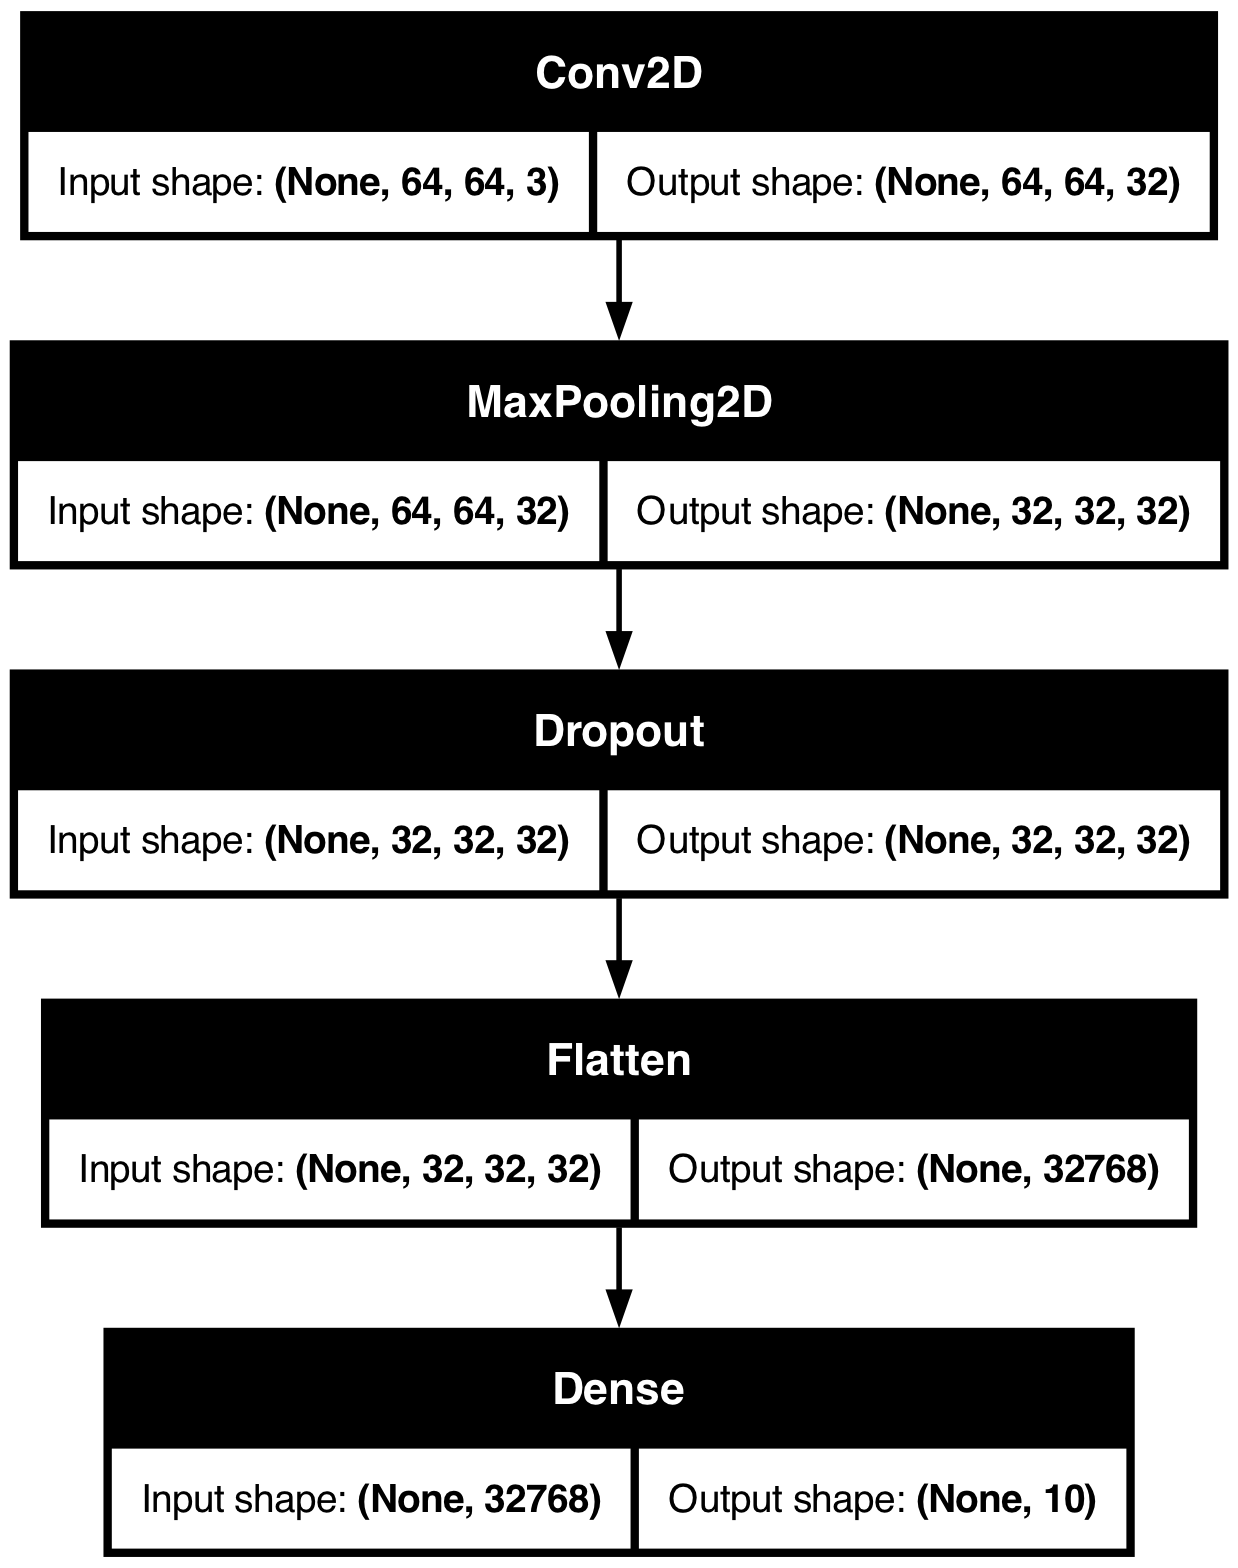

In [49]:
model_four_nn = Sequential([
    Input(shape=(img_width, img_height, 3)), 
    Conv2D(32, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),
    Dropout(0.3, seed=42),
    Flatten(),
    Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10))
])

model_four_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

plot_model(model_four_nn, to_file='model_four_nn.png', show_shapes=True)

In [50]:
history = model_four_nn.fit(X_train_original, y_train_cat, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.3632 - loss: 1.8253 - val_accuracy: 0.5932 - val_loss: 1.1685
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5581 - loss: 1.2112 - val_accuracy: 0.5784 - val_loss: 1.1119
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6163 - loss: 1.0758 - val_accuracy: 0.5877 - val_loss: 1.0701
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6490 - loss: 1.0046 - val_accuracy: 0.5401 - val_loss: 1.1734
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6837 - loss: 0.9214 - val_accuracy: 0.5543 - val_loss: 1.1290
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7118 - loss: 0.8535 - val_accuracy: 0.5623 - val_loss: 1.1519
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7313 - loss: 0.8018 - val_accuracy: 0.5840 - val_loss: 1.1114
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7531 - loss: 0.7419 - val_accu

In [51]:
loss, accuracy = model_four_nn.evaluate(X_test_original, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5910 - loss: 1.2233
Test accuracy: 0.5969


In [52]:
print(f"Model One Parameters: {model_one_nn.count_params()}")
print(f"Model Two Parameters: {model_two_nn.count_params()}")
print(f"Model Three Parameters: {model_three_nn.count_params()}")
print(f"Model Four Parameters: {model_four_nn.count_params()}")

Model One Parameters: 40970
Model Two Parameters: 205360
Model Three Parameters: 210460
Model Four Parameters: 328586


We observe a significant increase in accuracy with the CNN model compared to the previous models. This is because CNNs are designed to learn spatial relationships between features, making them more effective for image classification tasks. In contrast, the previous models were fully connected networks that processed flattened inputs, thereby losing the spatial structure of the images.

CNN models excel at capturing spatial information by learning spatial dependencies within an image using convolutional filters. In fully connected models, flattening the data for input removes this spatial structure. As a result, CNNs generally outperform fully connected networks in image classification tasks, as images inherently contain spatial information. However, CNNs also have a higher number of parameters, as seen above, which increases computational requirements and training time.

### 3.2.2 Model Five

**Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate** **classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?**

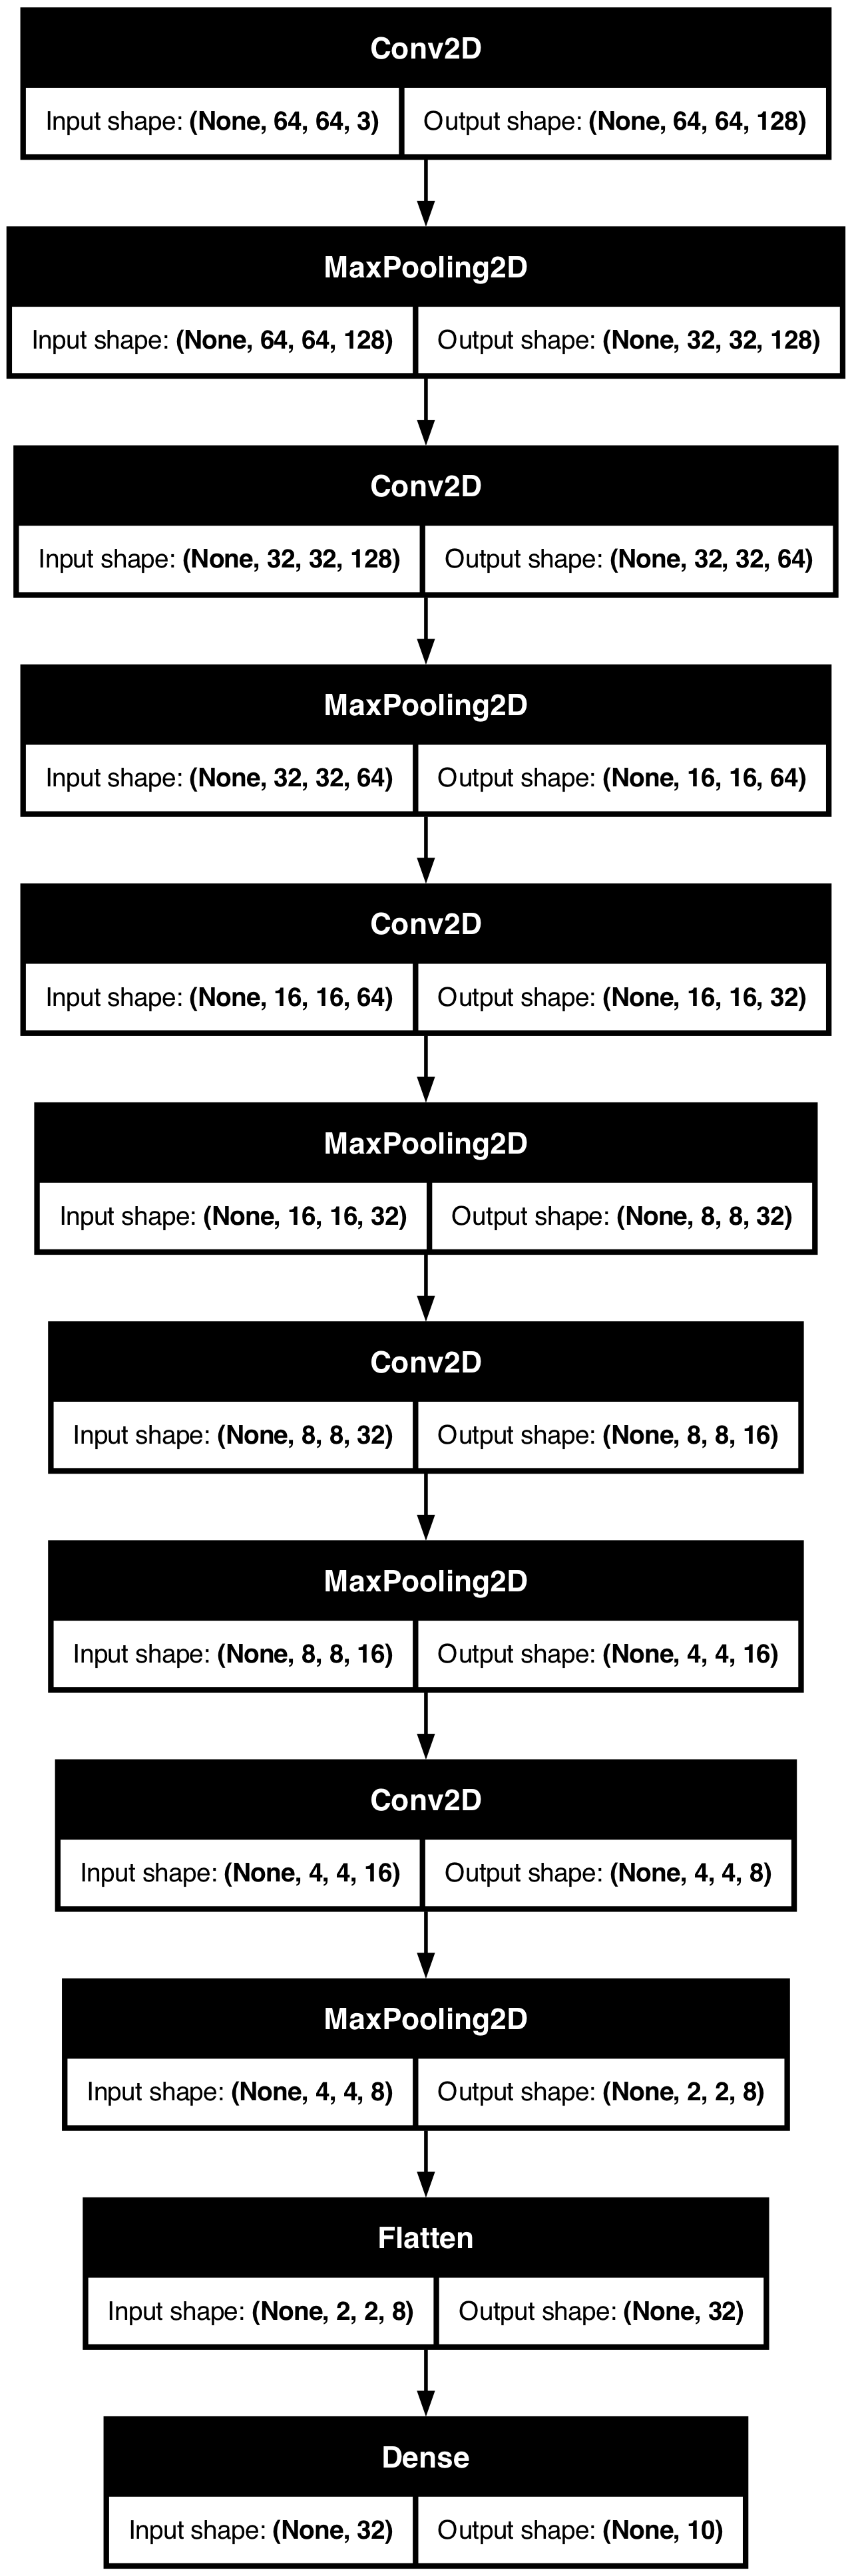

In [53]:
model_five_nn = Sequential([
    Input(shape=(img_width, img_height, 3)), 
    
    Conv2D(128, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(32, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(16, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(8, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Flatten(),

    Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10))
])

model_five_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

plot_model(model_five_nn, to_file='model_five_nn.png', show_shapes=True)

In [54]:
history = model_five_nn.fit(X_train_original, y_train_cat, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.3230 - loss: 1.7516 - val_accuracy: 0.5889 - val_loss: 1.1419
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 55s 121ms/step - accuracy: 0.6133 - loss: 1.0373 - val_accuracy: 0.6907 - val_loss: 0.8571
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 59s 130ms/step - accuracy: 0.6994 - loss: 0.8396 - val_accuracy: 0.6827 - val_loss: 0.8546
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - accuracy: 0.7354 - loss: 0.7496 - val_accuracy: 0.7568 - val_loss: 0.7232
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 61s 133ms/step - accuracy: 0.7660 - loss: 0.6707 - val_accuracy: 0.7574 - val_loss: 0.7120
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 60s 132ms/step - accuracy: 0.7821 - loss: 0.6255 - val_accuracy: 0.7630 - val_loss: 0.7134
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 61s 135ms/step - accuracy: 0.7961 - loss: 0.5880 - val_accuracy: 0.7623 - val_loss: 0.7312
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 67s 147ms/step - accuracy: 0.8163 - loss: 0

In [55]:
loss, accuracy = model_five_nn.evaluate(X_test_original, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

338/338 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.7957 - loss: 0.6109
Test accuracy: 0.7944


In Model Four, I observed a significant increase in accuracy after incorporating Conv and MaxPool layers. Building on this increase, I replicated the same block in Model Five while increasing the number of filters to capture more spatial relationships. Additionally, I removed the Dropout layers, as previous models indicated that, at this stage, the model complexity was not high enough to benefit from regularization. These adjustments led to a substantial improvement in accuracy, allowing Model Five to better capture spatial dependencies and achieve a superior fit to the data.

**What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?**

In [56]:
predprob = model_five_nn.predict(X_test_original)
pred_labels = np.argmax(predprob, axis=1)

338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step


In [57]:
cm = confusion_matrix(y_test, pred_labels)

In [58]:
label_error = (cm.sum(axis=1) - np.diag(cm)) / cm.sum(axis=1)

In [59]:
sorted_indices = np.argsort(label_error)[::-1]
top_two_names = [inv_class_indices[i] for i in sorted_indices[:2]]

In [60]:
print('label with highest error:', top_two_names[0], label_error[sorted_indices[0]],'percent true labels misclassified')
print('label with second highest error:', top_two_names[1], label_error[sorted_indices[1]],'percent true labels misclassified')

label with highest error: PermanentCrop 0.465 percent true labels misclassified
label with second highest error: Highway 0.422 percent true labels misclassified


In [61]:
misclassified_label1= np.where((y_test == sorted_indices[0]) & (pred_labels != sorted_indices[0]))
misclassified_label2= np.where((y_test == sorted_indices[1]) & (pred_labels != sorted_indices[1]))

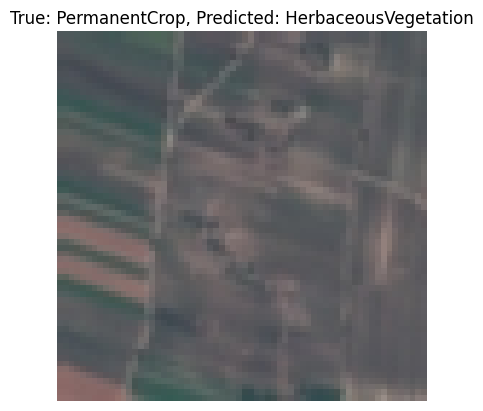

In [62]:
idx = misclassified_label1[0][1]
plt.imshow(X_test_original[idx])
plt.title(f"True: {inv_class_indices[y_test[idx]]}, Predicted: {inv_class_indices[pred_labels[idx]]}")
plt.axis('off')
plt.show()

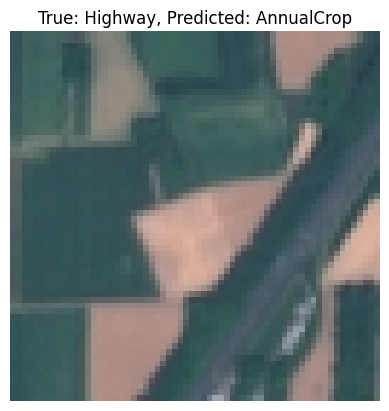

In [63]:
idx = misclassified_label2[0][1]
plt.imshow(X_test_original[idx])
plt.title(f"True: {inv_class_indices[y_test[idx]]}, Predicted: {inv_class_indices[pred_labels[idx]]}")
plt.axis('off')
plt.show()

The labels with the highest labeling error, defined as the percentage of true labels that were misclassified, are PermanentCrop and Highway. This issue becomes evident when we examine the misclassified images. Highways are relatively linear features that often pass through other landscape categories, such as Pastures, making it difficult for the model to distinguish them accurately. Similarly, PermanentCrop can resemble other features like AnnualCrop or HerbaceousVegetation, leading to frequent misclassification.

Increasing the number of training examples for these labels could help the model learn finer distinctions between them. Additionally, using higher-resolution images that cover a broader area might provide more contextual information, improving classification accuracy. Incorporating hyperspectral imagery in training could further enhance the model's ability to differentiate these features by capturing unique spectral signatures.

## 3.3 Multispectral Images

**Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.**

**How did adding multispectral channels impact your model’s performance? Explain the role of additional spectral information in enhancing land cover classification.**

In [64]:
tif_files = glob.glob(os.path.join('EuroSAT_MS', '*', '*.tif'))

ms_images = []
ms_labels = []

for file in tif_files:
    img = tifffile.imread(file)
    ms_images.append(img)
    label = os.path.basename(os.path.dirname(file))
    ms_labels.append(label)

In [65]:
n_channels = 13
ms_images = np.array(ms_images)[:,:,:,0:n_channels]
ms_labels = np.array(ms_labels)

In [66]:
max_per_band = ms_images.max(axis=(0, 1, 2), keepdims=True)
ms_images_normalized = ms_images / max_per_band

In [67]:
class_to_idx = {v: k for k, v in inv_class_indices.items()}
ms_labels_numeric = np.array([class_to_idx[label] for label in ms_labels])

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    ms_images_normalized, ms_labels_numeric, test_size=0.4, stratify=ms_labels_numeric, random_state=42
)

In [69]:
num_classes = len(class_indices)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [70]:
model_six_nn = Sequential([
    Input(shape=(img_width, img_height, n_channels)), 
    
    Conv2D(128, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(32, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(16, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Conv2D(8, (3, 3), padding='same', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10)),
    MaxPool2D((2, 2)),

    Flatten(),

    Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=10))
])

model_six_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [71]:
history = model_six_nn.fit(X_train, y_train_cat, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 73s 156ms/step - accuracy: 0.4870 - loss: 1.4417 - val_accuracy: 0.7401 - val_loss: 0.7489
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 83s 183ms/step - accuracy: 0.7259 - loss: 0.7686 - val_accuracy: 0.7907 - val_loss: 0.5691
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 96s 210ms/step - accuracy: 0.7715 - loss: 0.6371 - val_accuracy: 0.8074 - val_loss: 0.5364
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 92s 201ms/step - accuracy: 0.8016 - loss: 0.5454 - val_accuracy: 0.8253 - val_loss: 0.5019
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 97s 213ms/step - accuracy: 0.8251 - loss: 0.4991 - val_accuracy: 0.8463 - val_loss: 0.4482
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 123s 270ms/step - accuracy: 0.8391 - loss: 0.4592 - val_accuracy: 0.8488 - val_loss: 0.4255
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 126s 276ms/step - accuracy: 0.8535 - loss: 0.4227 - val_accuracy: 0.8642 - val_loss: 0.3952
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 119s 262ms/step - accuracy: 0.8619 - loss

In [72]:
loss, accuracy = model_six_nn.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

338/338 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.8711 - loss: 0.3848
Test accuracy: 0.8688


Using all 13 spectral channels, rather than just the RGB channels used in previous models, significantly improved our accuracy. This improvement can be attributed to the additional information captured by the extra bands, which enhance model predictions. For instance, bands 11, 8, and 2 provide distinct spectral signatures that aid in distinguishing agricultural features more effectively.

# 4. Reflection Questions

**What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? If you answered the bonus questions, how did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?**

One key observation regarding parameter tuning is that it is largely arbitrary. Apart from extreme values, there is no single "correct" parameter value. At best, the feasible range depends on the application context. Beyond that, final test accuracy serves as the best guide for selecting parameters. Therefore, it is advisable to experiment with different models and parameter values, selecting the configuration that yields the best performance.

Naturally, increasing the number of training epochs improves model performance—up to a point. After a certain threshold, additional epochs do not contribute further improvements. Moreover, increasing epochs comes at the cost of extended training time, which can be a significant limitation.

Dropout proved effective in preventing overfitting, making the model more generalizable. However, it must be used judiciously, especially in simpler models. In cases where the model is not complex, such as Model Three, or when too many Dropout layers are applied, underfitting can occur.

The biggest challenge, however, remains computational power. Initially, I attempted transfer learning techniques using VGG16 in Models Five and Six, but due to their complexity, training times were excessively long. As a result, I had to explore alternative approaches. The simplest solution to this challenge would be to use a more powerful machine or leverage cloud-based computing.

Deep learning applications vary significantly, but through this assignment, I have learned a few key lessons:

* More compute power leads to better efficiency.
* Preprocessing and normalization are crucial for improving performance.
* Techniques like Dropout, when used correctly, can significantly help prevent overfitting, but they can also hinder performance if misapplied.

# Citation

**Data Accessed From:** Helber, P., Bischke, B., Dengel, A., & Borth, D. (2018). EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification [Data set]. In EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification (Vol. 12, Number 7, pp. 2217–2226). Zenodo. https://doi.org/10.5281/zenodo.7711810

AI support was sought sparingly, but throughout the notebook using:

OpenAI. (2025). ChatGPT (Apr 1, 2025  version) [Large language model]. 
    https://chat.openai.com/chat